# Exploratory Data Analysis — Agmarknet Mandi Price Dataset

This notebook performs a full EDA on the cleaned Agmarknet dataset, step by step.
Each markdown cell explains **what** the next code cell does and **why**, so you can
learn the reasoning, not just copy the code.

**Input:** `agmarknet_cleaned.csv` (output of the earlier data cleaning notebook).

The analysis follows four stages: Data Overview, Statistical Analysis (univariate +
bivariate), Visualization, and Insight Generation — matching a standard EDA workflow.

## Step 0 — Import libraries

`pandas` for data handling, `numpy` for numerical operations, `matplotlib` for charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Step 1 — Load the cleaned dataset and get oriented

Before analyzing anything, establish the basic facts: how many rows and columns, and
which columns are numeric (measurements) vs categorical (labels). This matters because
numeric and categorical columns need completely different kinds of analysis — you
summarize numeric columns with statistics like mean and std dev, but categorical columns
with frequency counts instead.

In [2]:
df = pd.read_csv("agmarknet_cleaned.csv")  # change path if needed

print("Shape:", df.shape)
df.dtypes

Shape: (9603, 17)


State                         str
District                      str
Market                        str
Commodity                     str
Variety                       str
Grade                         str
Arrival_Date                  str
Min_Price                 float64
Max_Price                 float64
Modal_Price               float64
Grade_Category                str
Price_Outlier_Flag           bool
Spread_Ratio              float64
Spread_Anomaly_Flag          bool
Suspected_Unit_Error         bool
Price_Range               float64
Modal_Price_Normalized    float64
dtype: object

In [3]:
df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Grade_Category,Price_Outlier_Flag,Spread_Ratio,Spread_Anomaly_Flag,Suspected_Unit_Error,Price_Range,Modal_Price_Normalized
0,Tripura,Dhalai,Kulai APMC,Bhindi(Ladies Finger),Bhindi,Grade B,23/08/2026,5500.0,6000.0,5800.0,Quality Grade,False,1.090909,False,False,500.0,0.773321
1,Tripura,Dhalai,Kulai APMC,Sponge gourd,Other,Grade B,23/08/2026,7500.0,8000.0,7700.0,Quality Grade,False,1.066667,False,False,500.0,1.000000
2,Tripura,Dhalai,Kulai APMC,Bitter gourd,Bitter Gourd,Grade B,23/08/2026,9600.0,10000.0,9800.0,Quality Grade,True,1.041667,False,False,400.0,0.979999
3,Kerala,Kozhikode(Calicut),Mukkom Market,Banana,Other,Large,23/08/2026,6300.0,6500.0,6400.0,Size Grade,False,1.031746,False,False,200.0,0.639874
4,Kerala,Kozhikode(Calicut),Mukkom Market,Banana - Green,Banana - Green,FAQ,23/08/2026,6300.0,6500.0,6400.0,Quality Grade,True,1.031746,False,False,200.0,0.590909


## Step 2 — Define which columns are numeric vs categorical

We'll analyze these two groups differently throughout the notebook, so it's worth being
explicit about the split upfront rather than re-deciding it every time.

In [4]:
numeric_cols = ["Min_Price", "Max_Price", "Modal_Price", "Price_Range", "Spread_Ratio"]
categorical_cols = ["State", "Commodity", "Grade_Category"]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Min_Price', 'Max_Price', 'Modal_Price', 'Price_Range', 'Spread_Ratio']
Categorical columns: ['State', 'Commodity', 'Grade_Category']


## Step 3 — Univariate analysis: numeric variables

"Univariate" just means "one variable at a time." For each numeric column we compute:

- **Mean and median** — two different measures of "center." When they're far apart, the
  data is skewed (lopsided), not symmetric.
- **Standard deviation** — how spread out the values typically are.
- **Skewness** — a single number that measures how lopsided the distribution is. Zero
  means symmetric; a large positive number means a long tail stretching toward high
  values (which is exactly what we'd expect from commodity prices — most trades happen
  at a normal price, with a few expensive outliers pulling the tail rightward).
- **Coefficient of variation** (std ÷ mean) — this tells you the *relative* spread. A
  value above 100% means the spread is larger than the average itself — a sign that very
  different scales are mixed together in one column (cheap potatoes and expensive garlic,
  in this case).

**Why this matters:** don't just report the mean and stop. On skewed data the mean can be
a misleading "typical value" — pairing it with the median and skewness tells you whether
you can trust it.

In [5]:
univariate_stats = df[numeric_cols].describe().T
univariate_stats["skew"] = df[numeric_cols].skew()
univariate_stats["cv_pct"] = (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(2)
univariate_stats.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,cv_pct
Min_Price,9603.0,5098.82,5838.38,0.3,2500.0,4000.00,5800.0,131500.00,9.67,114.50
Max_Price,9603.0,5754.82,6314.97,0.3,3000.0,4400.00,6200.0,135000.00,8.66,109.73
Modal_Price,9603.0,5428.42,6048.71,0.3,2750.0,4100.00,6000.0,133088.68,9.22,111.43
Price_Range,9603.0,656.00,1249.36,0.0,0.0,500.00,800.0,45000.00,10.03,190.45
Spread_Ratio,9603.0,1.20,1.34,1.0,1.0,1.11,1.2,117.65,70.17,112.09


## Step 4 — Univariate analysis: categorical variables

For categorical columns, the equivalent of "mean and spread" is: how many unique
categories exist, and how concentrated is the data among them? A column where one
category dominates (say, 70% of records from a single state) needs a different
interpretation than one that's evenly spread — conclusions drawn from a heavily
concentrated column may just reflect that one dominant category, not a general pattern.

In [6]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print("Unique values:", df[col].nunique())
    top5 = df[col].value_counts().head(5)
    print(top5)
    print(f"Top category share: {100 * top5.iloc[0] / len(df):.2f}%\n")

--- State ---
Unique values: 23
State
Tamil Nadu       6716
Uttar Pradesh     726
Kerala            684
Maharashtra       266
Telangana         231
Name: count, dtype: int64
Top category share: 69.94%

--- Commodity ---
Unique values: 176
Commodity
Potato          308
Tomato          300
Brinjal         290
Onion           278
Green Chilli    261
Name: count, dtype: int64
Top category share: 3.21%

--- Grade_Category ---
Unique values: 3
Grade_Category
Market Type      7325
Quality Grade    2030
Size Grade        248
Name: count, dtype: int64
Top category share: 76.28%



## Step 5 — Bivariate analysis: correlation between numeric variables

"Bivariate" means looking at two variables together to see if they move in relation to
each other. Correlation is a number between -1 and 1: close to 1 means two variables rise
and fall together, close to -1 means one rises as the other falls, and close to 0 means no
linear relationship at all.

We'd expect Min_Price, Max_Price, and Modal_Price to be very highly correlated with each
other — they're three closely related measurements of the same trade, so this is more of
a sanity check than a discovery. The genuinely interesting question is whether
`Spread_Ratio` (a measure of daily price volatility) correlates with the price level
itself — if it doesn't, that tells us volatility is a separate phenomenon from price
size, which is a real, non-obvious insight.

In [7]:
corr = df[numeric_cols].corr(method="pearson").round(3)
corr

,Min_Price,Max_Price,Modal_Price,Price_Range,Spread_Ratio
Min_Price,1.000,0.982,0.995,0.290,-0.046
Max_Price,0.982,1.000,0.995,0.466,0.006
Modal_Price,0.995,0.995,1.000,0.376,-0.013
Price_Range,0.290,0.466,0.376,1.000,0.248
Spread_Ratio,-0.046,0.006,-0.013,0.248,1.000


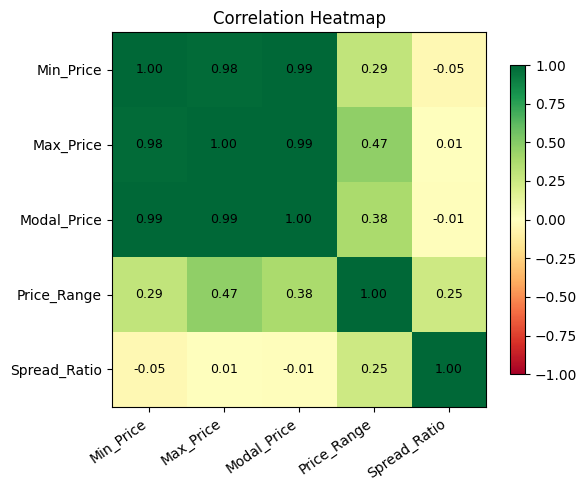

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=35, ha="right")
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Correlation Heatmap")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Step 6 — Bivariate analysis: grouping by category

This is arguably the single most useful technique in EDA: `groupby()`. It answers the
question "does this numeric variable differ across categories?" Here we check whether
average price differs meaningfully by state and by commodity — if it does, that's a real
pattern worth investigating further; if all groups look similar, price isn't really
driven by that category.

In [9]:
top_states = df["State"].value_counts().head(8).index.tolist()
state_price = (
    df[df["State"].isin(top_states)]
    .groupby("State")["Modal_Price"]
    .agg(["mean", "median", "std", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)
state_price

,mean,median,std,count
State,,,,
Kerala,6827.46,5500.0,6883.82,684
Tripura,6134.73,4100.0,6031.41,94
Tamil Nadu,5786.84,4500.0,5106.76,6716
Uttar Pradesh,3948.35,2410.0,11942.32,726
Odisha,3636.09,3200.0,1974.48,110
Maharashtra,3416.38,2500.0,3085.24,266
Telangana,3358.22,2600.0,4523.22,231
Madhya Pradesh,2984.02,2000.0,6090.71,136


In [10]:
top_commodities = df["Commodity"].value_counts().head(8).index.tolist()
commodity_price = (
    df[df["Commodity"].isin(top_commodities)]
    .groupby("Commodity")["Modal_Price"]
    .agg(["mean", "median", "std", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)
commodity_price

,mean,median,std,count
Commodity,,,,
Banana,5563.61,5500.0,1881.76,239
Bitter gourd,5249.25,5500.0,1954.65,251
Green Chilli,5212.28,5400.0,2293.13,261
Onion,4549.99,4750.0,1393.24,278
Brinjal,3894.38,3800.0,1511.29,290
Bhindi(Ladies Finger),3848.02,3750.0,1304.87,257
Potato,2468.32,2600.0,1704.37,308
Tomato,2069.25,2000.0,729.11,300


## Step 7 — Visualization: histogram

A histogram shows the overall **shape** of one variable's distribution — where values
cluster, and whether there's a long tail. We use a log scale on the x-axis here because
the values span several orders of magnitude (a few rupees to over a lakh); on a normal
scale, the chart would look like a single tall spike with an invisible tail.

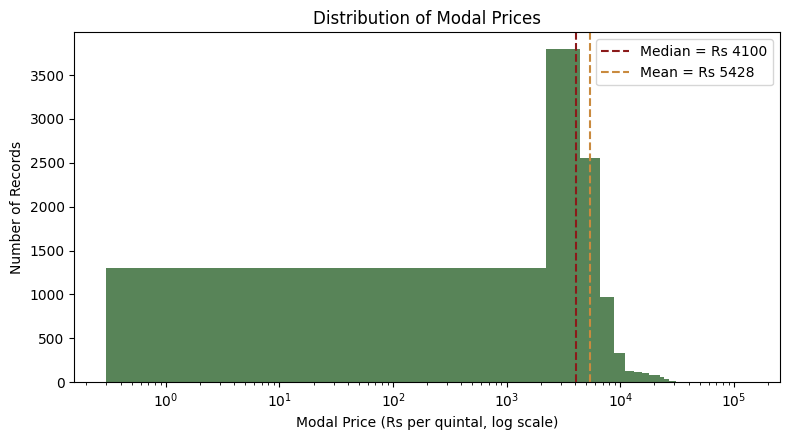

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["Modal_Price"], bins=60, color="#3b6e3b", alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Modal Price (Rs per quintal, log scale)")
ax.set_ylabel("Number of Records")
ax.set_title("Distribution of Modal Prices")
ax.axvline(df["Modal_Price"].median(), color="#8b1a1a", linestyle="--", label=f"Median = Rs {df['Modal_Price'].median():.0f}")
ax.axvline(df["Modal_Price"].mean(), color="#c98a3e", linestyle="--", label=f"Mean = Rs {df['Modal_Price'].mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — Visualization: box plot

A box plot shows spread **across categories** at a glance. The box itself covers the
middle 50% of values (Q1 to Q3), the line inside is the median, the whiskers extend to
the "typical" range, and individual dots beyond the whiskers are outliers. Comparing box
plots side by side answers: which commodities have consistent pricing, and which have
wide, unpredictable price ranges?

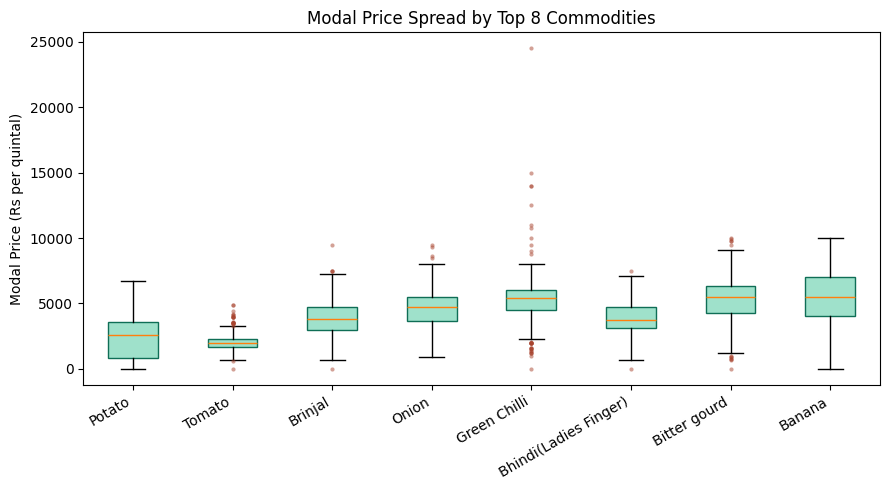

In [12]:
data_for_box = [df[df["Commodity"] == c]["Modal_Price"].values for c in top_commodities]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_for_box, tick_labels=top_commodities, patch_artist=True,
                 flierprops=dict(marker='o', markersize=3, markerfacecolor='#a8442f', markeredgecolor='none', alpha=0.5))
for patch in bp['boxes']:
    patch.set_facecolor('#9fe1cb')
    patch.set_edgecolor('#0f6e56')
ax.set_ylabel("Modal Price (Rs per quintal)")
ax.set_title("Modal Price Spread by Top 8 Commodities")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Step 9 — Visualization: scatter plot

A scatter plot shows the **relationship** between two continuous variables — here, Min
Price against Max Price. Since these should naturally move together, most points should
sit close to a diagonal line. Coloring the flagged outliers separately turns this into a
visual data-quality check too: points far off the diagonal, or unusually far along it,
are exactly the anomalies flagged earlier in preprocessing.

Note we explicitly print the counts in the legend — with skewed data, a small number of
outliers can visually cluster and look more dominant than they really are, so labeling
the actual n for each group keeps the chart honest.

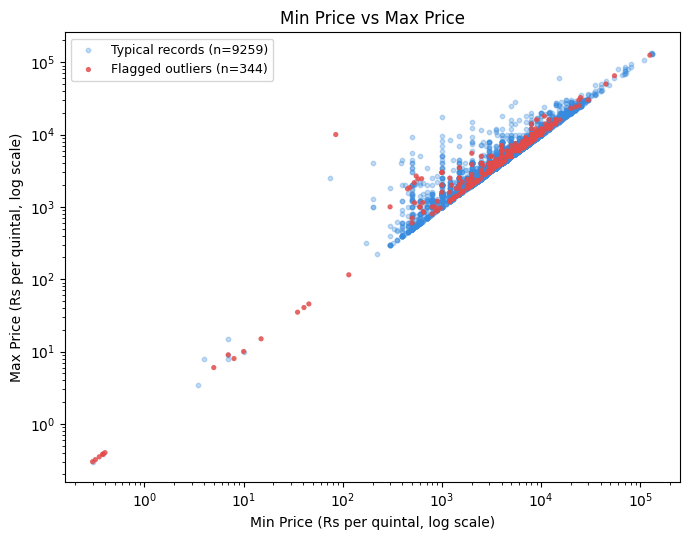

In [13]:
normal = df[~df["Price_Outlier_Flag"]]
outlier = df[df["Price_Outlier_Flag"]]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(normal["Min_Price"], normal["Max_Price"], s=10, alpha=0.3, color="#378add",
           label=f"Typical records (n={len(normal)})")
ax.scatter(outlier["Min_Price"], outlier["Max_Price"], s=14, alpha=0.85, color="#e24b4a",
           label=f"Flagged outliers (n={len(outlier)})", edgecolors="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Min Price (Rs per quintal, log scale)")
ax.set_ylabel("Max Price (Rs per quintal, log scale)")
ax.set_title("Min Price vs Max Price")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Step 10 — Visualization: bar chart

A bar chart is the simplest way to compare one summary number across categories — here,
mean modal price by state. It makes the ranking from Step 6's table immediately visible
without having to scan a table of numbers.

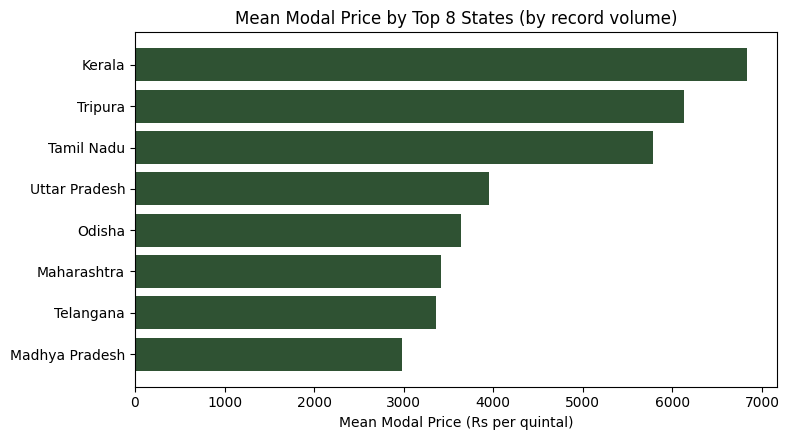

In [14]:
state_means = df[df["State"].isin(top_states)].groupby("State")["Modal_Price"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(state_means.index, state_means.values, color="#2f5233")
ax.set_xlabel("Mean Modal Price (Rs per quintal)")
ax.set_title("Mean Modal Price by Top 8 States (by record volume)")
plt.tight_layout()
plt.show()

## Step 11 — Insight generation

This is the step that turns numbers into decisions. The pattern to follow for each
finding: **statistical observation → what it means practically → what decision it could
change.** A few examples drawn from the analysis above:

- Spread_Ratio correlates near zero with price level (Step 5) → volatility is
  independent of how expensive a commodity is → a monitoring system that only tracks
  average price would miss volatility risk entirely, so it needs a separate metric.
- One commodity (from Step 8's box plot) shows a much wider spread and far more outliers
  than the others → that commodity's price signal may not be reliable for forecasting
  until you determine whether the spread reflects genuine grade segmentation or data
  issues.
- One state dominates the record count (Step 4) → any state-level comparison should be
  read as indicative, not definitive, since smaller states rest on much thinner samples.
- States with similar commodity mixes but different average prices (Step 6) → potential
  regional arbitrage worth investigating, if the price gap exceeds transport cost.

Write your own version of this for at least one finding from your own run of this
notebook before moving on — that's the actual skill this exercise is building.

## Next step

Use the tables and charts above directly as Section 2 (Statistical Analysis) and Section
3 (Visualization) material in your EDA report, and write your Section 4 (Insight
Generation) using the reasoning pattern from Step 11 above.